# Attribute Information:

1. Age of patient at time of operation (numerical) <br>
2. Patient's year of operation (year - 1900, numerical) <br>
3. Number of positive axillary nodes detected (numerical) <br>
4. Survival status (class attribute) <br>
-- 1 = the patient survived 5 years or longer <br>
-- 2 = the patient died within 5 year



In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv('haberman.csv')
df.head()

,age,year,nodes,status
0,30,64,1,1
1,30,62,3,1
2,30,65,0,1
3,31,59,2,1
4,31,65,4,1


In [3]:
df.shape

(306, 4)

In [4]:
#Q: How many data points for each class(status) are present?
df['status'].value_counts()
#This is unbalanced dataset

1    225
2     81
Name: status, dtype: int64

# 2D Scatter Plot

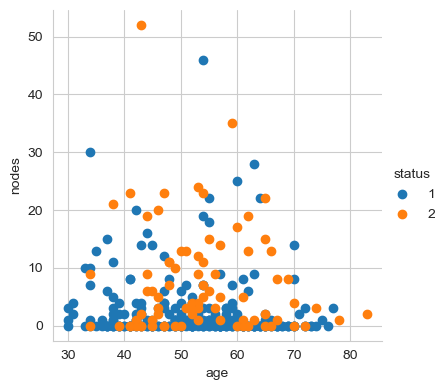

In [6]:
#2D scatter plot of node and age with color coding for each class
sns.set_style('whitegrid')
sns.FacetGrid(df,hue='status',height=4).map(plt.scatter,'age','nodes').add_legend()
plt.show()
#since most of points are overlapping cannot make much sense of it

# Pair Plot

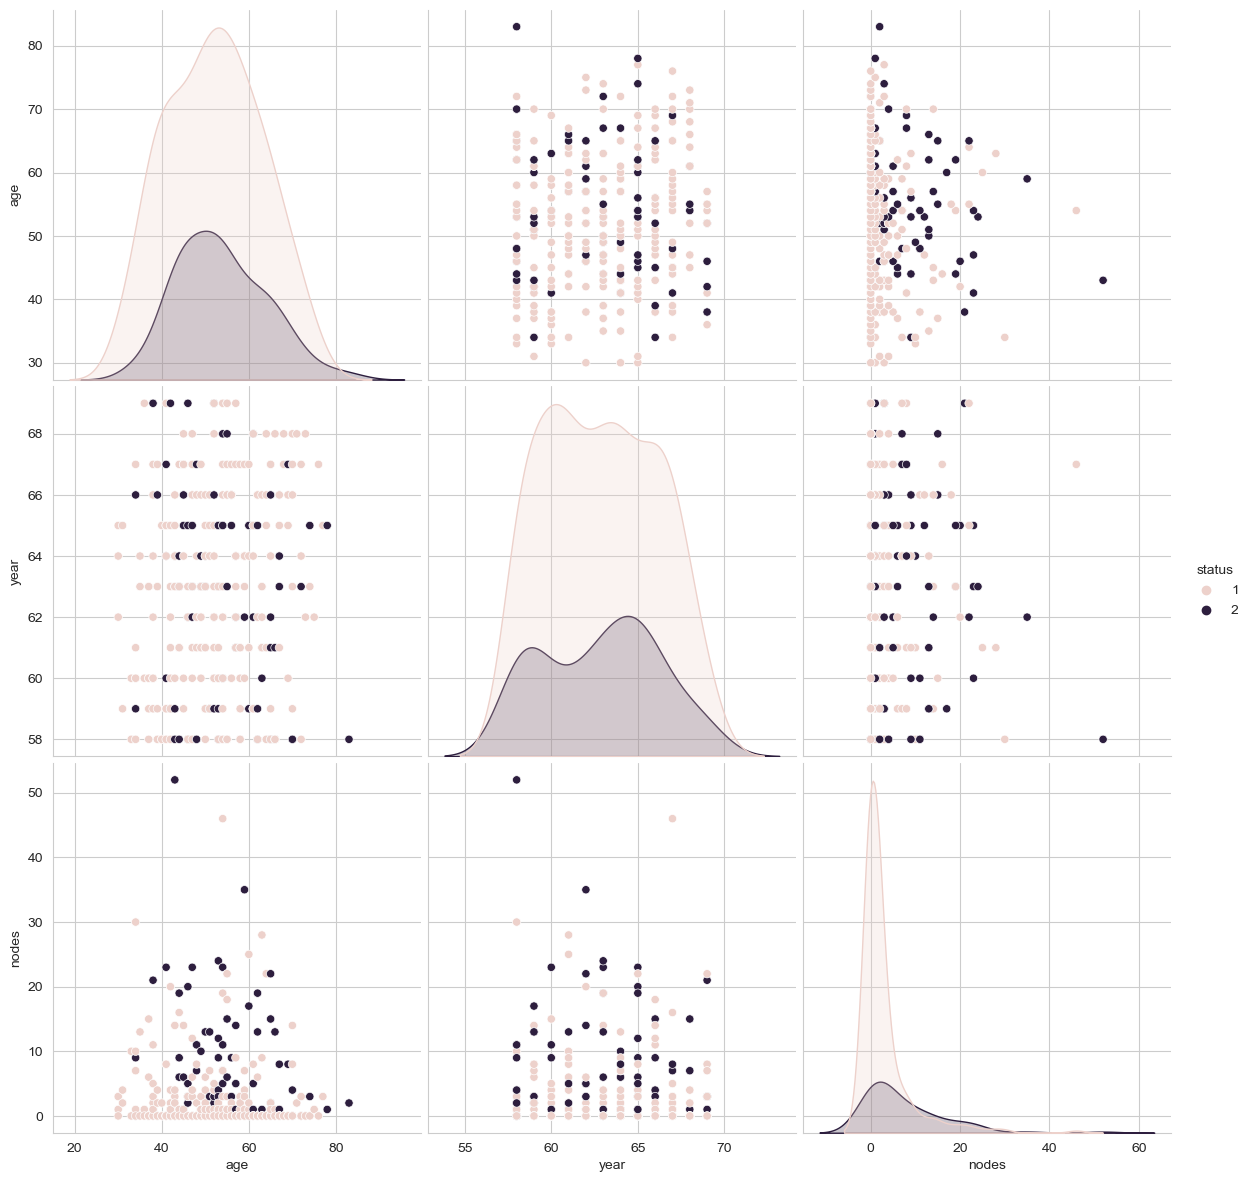

In [7]:
plt.close()
sns.set_style('whitegrid')
sns.pairplot(df,hue='status',height=4)
plt.show()
#can be used when number of features are high like 3d,4d,6d.

In [8]:
#Since most of our datapoints are overlapping in pairplot, we cannot make much sense of it.
#Lets do Univariate analysis.

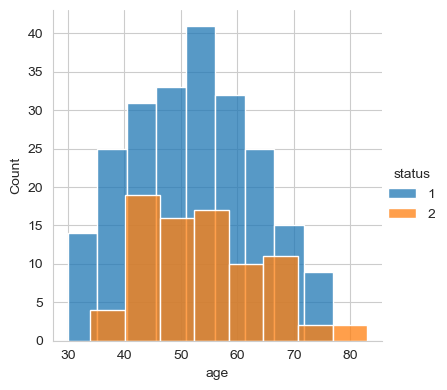

In [11]:
#1D scatter plot of age feature
sns.FacetGrid(df,hue='status',height=4).map(sns.histplot,'age').add_legend()
plt.show()

In [28]:
#Looks like patient who belong to agegroup 30 to 40 have higher chance of surviving more than 5 years after operation.
#lets find out number
age30_40 = df[(df['age']>=30) & (df['age']<=40)]
age30_40['status'].value_counts()


1    39
2     4
Name: status, dtype: int64

In [34]:
#lets do same for age group 41 to 50
age41_50 = df[(df['age']>=41) & (df['age']<=50)]
age41_50['status'].value_counts()

1    64
2    29
Name: status, dtype: int64

In [36]:
#age 51 to 60
age51_60 = df[(df['age']>=51) & (df['age']<=60)]
age51_60['status'].value_counts()

1    67
2    26
Name: status, dtype: int64

# Observations:
- Out of 43 patients who belong to age group 30 to 40, 39 of them survived more than five years after operation. <br>
- Out of 93 patients who belong to age group 41 to 50, 64 of them survived more than five years after operation. <br>

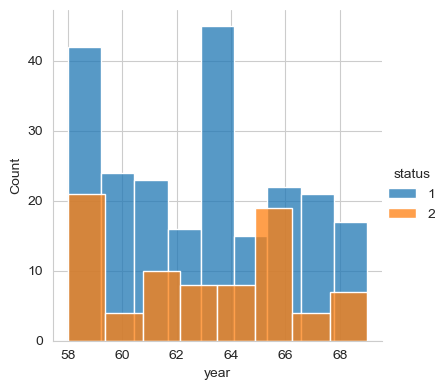

In [35]:
#Univariate analysis on 'year_of_operation' Feature
sns.FacetGrid(df,hue='status',height=4).map(sns.histplot,'year').add_legend()
plt.show()

# Obversations:
- Between year 1962 to 1964, more number of patients undergone operation, and more number of patients survived more than 5 years of operation.
- Lets find out number:
- Out of 84 patients who undergone surgery inbetween year 1962 to 1964, 61 of them survived for more than 5 years of operation.

In [40]:
year62_64 = df[(df['year']>=62) & (df['year']<=64)]
year62_64['status'].value_counts()

1    61
2    23
Name: status, dtype: int64

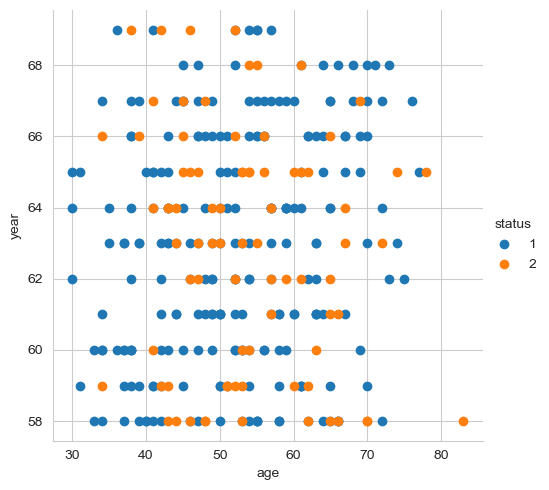

In [43]:
#Bi-variate analysis on age and year of operation feature.
sns.FacetGrid(df,hue='status',height=5).map(plt.scatter,'age','year').add_legend()
plt.show()

# Conclusion:
- Since most of our data are overlapping, we cannot built proper ML model from this data.
- we can have lots of misclassification error, we can only give probability score of chance of survival by using age feature.
-  We can say if patients belong to agegroup of 30_40, he have:
- 39/43 =  0.90 Probability of surviving more than 5 years after operation